In [161]:
# Mudança de fonte das cédulas markdown:
from IPython.core.display import HTML

HTML('''
<style>
    /* Altera a fonte nas células Markdown */
    div.text_cell_render {
        font-family: 'Verdana', sans-serif;
        font-size: 15px;
        color: black;
    }
</style>
''')

## Importar módulos:

In [162]:
from PIL import Image
import requests
import matplotlib.pyplot as plt
import numpy as np

## Abrir imagem escolhida

In [163]:
image = Image.open("beatles.jpg")

## Converter e exibir a imagem

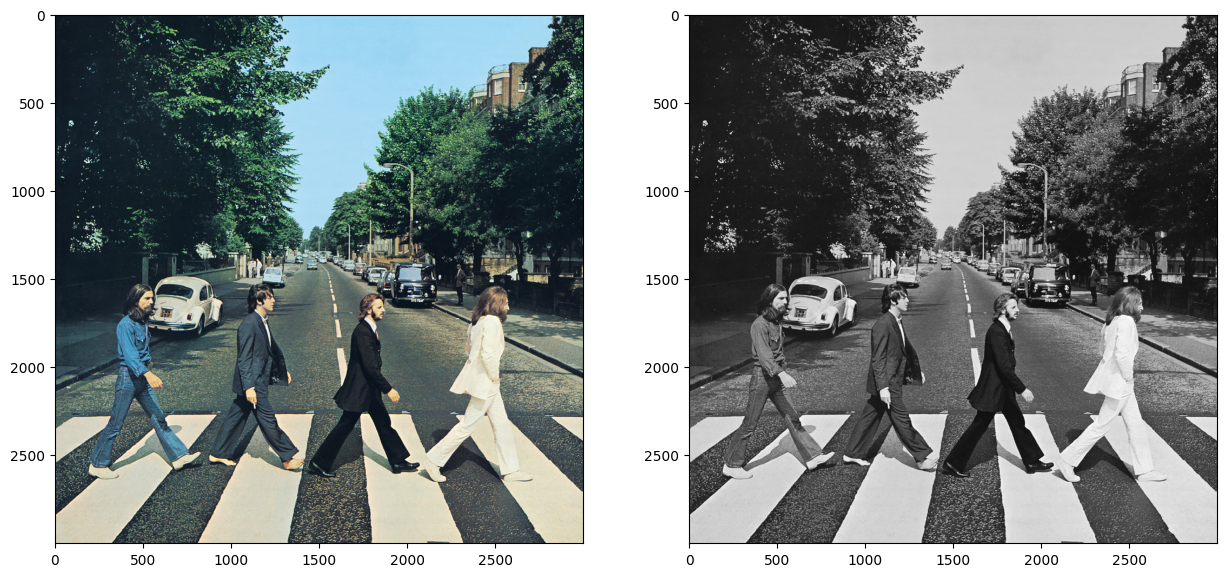

O modo da imagem é: L


In [164]:
#Conversão da imagem:
image_gray = image.convert("L")

# Representação da imagem escolhida:
fig, ax = plt.subplots (1,2, figsize=(15,8))
ax[0].imshow(image) #Policromática
ax[1].imshow(image_gray, cmap="gray") #Monocromática
plt.show()

# Mostrar que a imagem é monocromática
print(f"O modo da imagem é: {image_gray.mode}")

## 1) Visualizar o histograma desta imagem. Faça uma análise do mesmo e discuta com base no brilho e contraste da imagem.

In [76]:
# Transformar matrix(2D) em array:
img_array = np.array(image_gray)
print(img_array)

[[ 25  23  21 ...  27  27  27]
 [ 25  24  23 ...  28  28  27]
 [ 25  25  24 ...  28  28  28]
 ...
 [208 207 206 ... 217 217 217]
 [203 203 203 ... 217 217 218]
 [200 200 200 ... 215 216 217]]


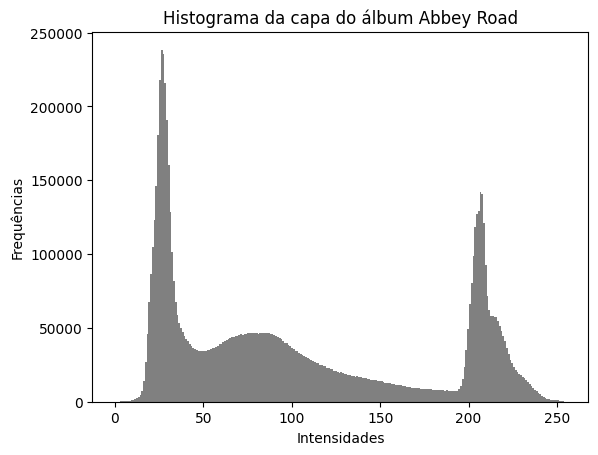

In [165]:
# Exibir o histograma:
plt.hist(img_array.flatten(), bins=256, width=1.0, color='gray')

plt.title('Histograma da capa do álbum Abbey Road')
plt.xlabel('Intensidades')
plt.ylabel('Frequências')

plt.show()

Discussão: O histograma apresenta uma quantidade distribuída de intensidades,com dois picos: ≈25 e ≈210, poucos pixels próximos de 0 e 255. Além disso, a presença de pixels em uma faixa ampla de 0 a 255 sugere que a imagem não é nem excessivamente escura (subexposta) nem excessivamente clara (superexposta), mantendo um equilíbrio. Por fim, o contraste é alto, visto que há dois picos distintos e separados: um à esquerda (tons escuros, provavelmente o asfalto, árvores e ternos escuros) e outro à direita (tons claros, como a faixa de pedestres, a calçada e o céu/camisas brancas).

## 2) Normalizar esse histograma e apresentar o resultado. Discuta o significado deste histograma normalizado.

In [147]:
# Função calcular o histograma:
def my_histogram(matriz):
    hist = np.zeros(256)
    for pixel in matriz.flatten():
        hist[pixel] += 1
    return hist

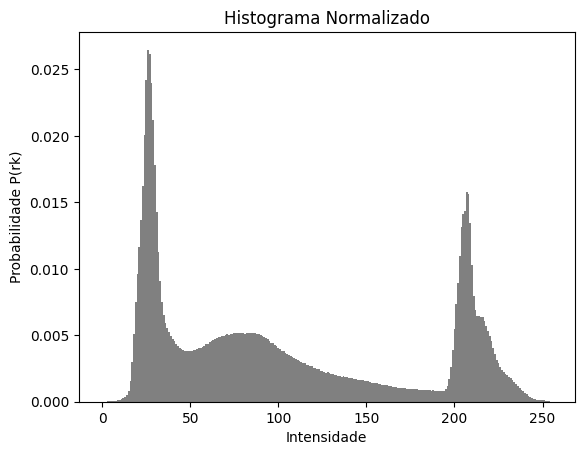

In [122]:
# Instânciar a função criada:
hist = my_histogram(img_array.flatten())

# Normalizar o histograma (fórmula):
total_pixels = img_array.shape[0] * img_array.shape[1]
hist_norm = hist / total_pixels

# Exibir o histograma normalizado:
plt.bar(range(256), hist_norm, width=1.0, color='gray')
plt.title('Histograma Normalizado')
plt.xlabel('Intensidade')
plt.ylabel('Probabilidade P(rk)')
plt.show()

In [123]:
# Soma dos histograma:
soma_total = np.sum(hist_norm)
print(f"A soma de todos os valores do histograma normalizado é: {soma_total}")

A soma de todos os valores do histograma normalizado é: 1.0


O histograma normalizado representa a função de probabilidade da imagem, logo é realemnte necessário que a soma de todos os valores seja igual a 1. Dessa forma, é possível comparar o brilho de imagens com resoluções diferentes, pois não dependemos mais do número total de pixels, mas sim da sua distribuição relativa.

## 3) Com base nas informações do histograma da imagem original, execute uma transformação linear sobre sua imagem que a deixe escura. Importante: ainda deve ser possível visualizar a imagem e o padrão do histograma não deve apresentar sinais de truncamento. Apresente a imagem transformada e seu respectivo histograma e discuta.

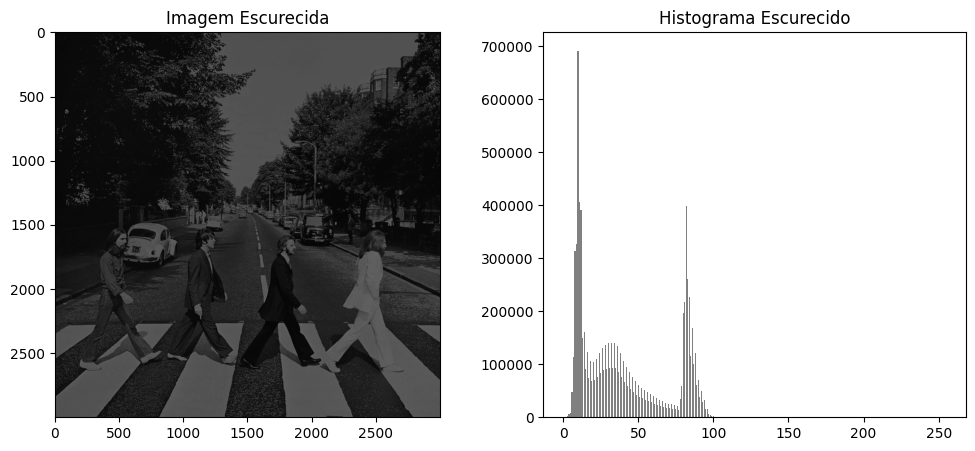

In [166]:
# Escurecer imagem (multiplicando por 0.4):
img_dark = (img_array * 0.4).astype(np.uint8)

# Instanciar a função criada: 
hist_dark = my_histogram(img_dark.flatten())

# Exibir histograma da imagem escura:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img_dark, cmap='gray', vmin=0, vmax=255)
ax[0].set_title("Imagem Escurecida")
ax[1].bar(range(256), hist_dark, color='gray')
ax[1].set_title("Histograma Escurecido")
plt.show()

Discussão: O histograma "encolheu" e se deslocou para a esquerda (valores baixos).

## 4) Com base nas informações do histograma da imagem original, execute uma transformação linear sobre sua imagem que a deixe com o contraste reduzido. Importante: ainda deve ser possível visualizar a imagem. Apresente a imagem transformada e seu respectivo histograma e discuta.

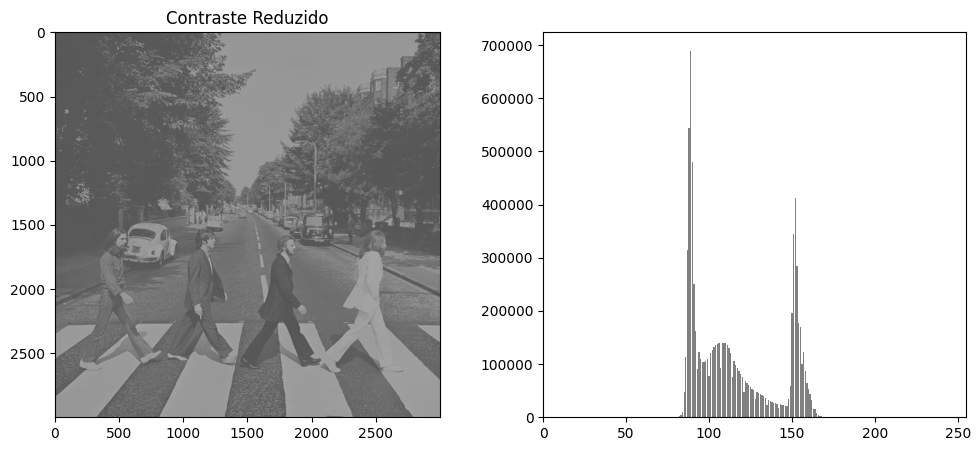

In [125]:
# Reduzir contraste:
img_low_contrast = (img_array * 0.35 + 80).astype(np.uint8)

# Instanciar a função:
hist_low = my_histogram(img_low_contrast.flatten())

# Exibir a imagem e o histograma:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img_low_contrast, cmap='gray', vmin=0, vmax=255)
ax[0].set_title("Contraste Reduzido")
ax[1].bar(range(256), hist_low, color='gray')
ax[1].set_xlim([0, 255])
plt.show()

Discussão: 

A transformação linear é do tipo $y=ax+b$. 

1. O termo Multiplicador ($a=0.35$): sua função é alterar o contraste da imagem, pois como $0.35$ é menor que $1$, está "achatando" a distância entre o pixel mais escuro e o mais claro. Como resultado, a diferença original entre um terno preto (0) e uma faixa branca (250) era de 250 tons, após a conta essa diferença cai para apenas $87$ tons ($250 \times 0.35$). Dessa forma, cria uma aparência "cinzenta", típica do baixo contraste.


2. O Termo  Offset ($b = 80$): sua função é deslocar o histograma para o centro da escala, isto é, se apenas multiplicar por $0.35$, a imagem ficaria muito escura (quase preta), pois os valores seriam muito baixos. Para resolver isso, soma-se $80$. Dessa forma, pode-se garantir que até o pixel que era preto puro ($0 \times 0.35 = 0$) vire um cinza médio ($80$). Isso "empurra" toda os dados do histograma para longe das bordas (0 e 255), concentrando tudo nos tons de cinza centrais.

## 5) Realize a equalização do histograma obtido no item 4, aplicando a transformação à imagem. Apresente a imagem obtida e seu respectivo histograma e discuta.

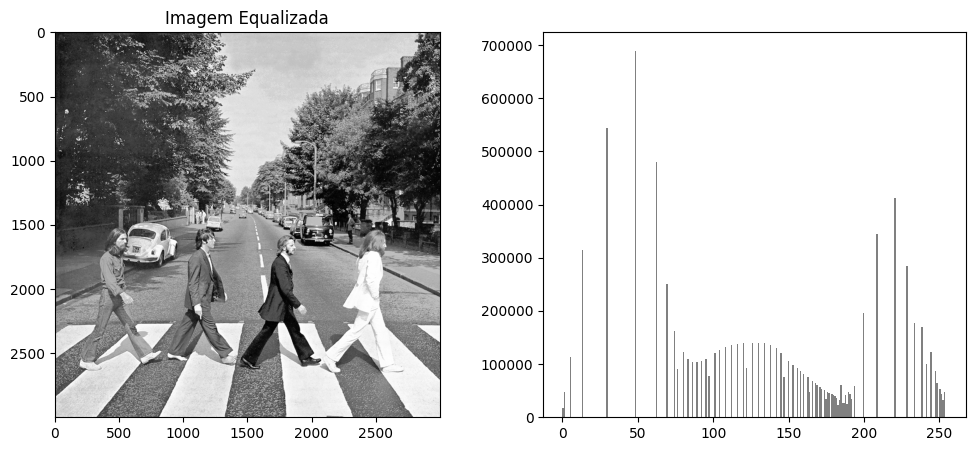

In [167]:
# Gerar histograma de baixo contraste:
h_low = my_histogram(img_low_contrast.flatten())

# Soma acumulada:
cdf = h_low.cumsum()
cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
cdf_normalized = cdf_normalized.astype(np.uint8)

# Mapear os pixels:
img_equalized = cdf_normalized[img_low_contrast]

# Exibir a imagem e histograma
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img_equalized, cmap='gray')
ax[0].set_title("Imagem Equalizada")
ax[1].hist(img_equalized.flatten(), bins=256, color='gray')
plt.show()

Discussão: A equalização recuperou o contraste da imagem original (ou até o acentuou). O histograma agora está mais "espalhado", utilizando melhor a faixa de 0 a 255.

## 6) Escolha uma nova imagem monocromática que mostre uma cena em primeiro plano e um fundo em segundo plano. Apresente o histograma desta imagem.

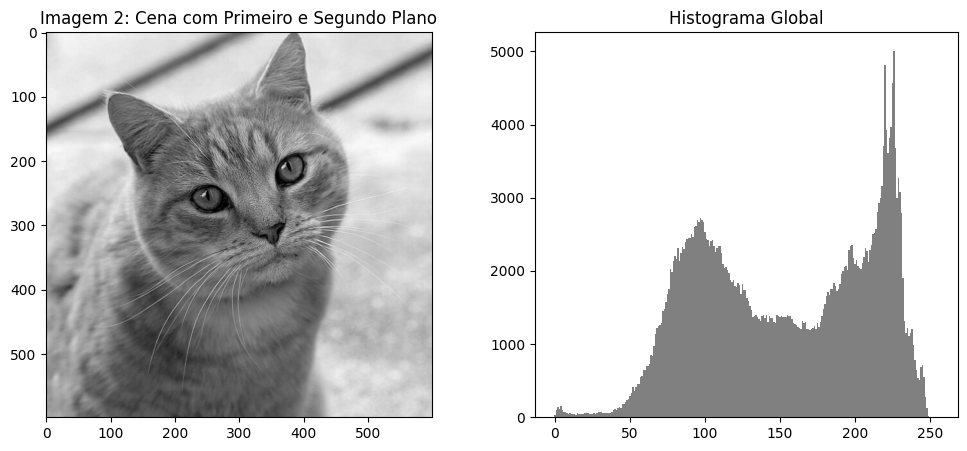

In [168]:
# Abrir nova imagem: 
img_new = Image.open("cat.jpg")

# Converter para monocromática (L):
img_new_gray = img_new.convert("L")

# Transformar matrix(2D) em array:
img_new_array = np.array(img_new_gray)
hist_global = my_histogram(img_new_array)

# Exibir imagem e histograma:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img_new_array, cmap='gray')
ax[0].set_title("Imagem 2: Cena com Primeiro e Segundo Plano")
ax[1].bar(range(256), hist_global, color='gray', width=1.0)
ax[1].set_title("Histograma Global")
plt.show()

O histograma desta imagem apresenta uma distribuição de intensidades bem distribuída, mas com concentrações específicas. Além disso, a imagem possui uma média de tons equilibrada (não é nem muito escura, nem muito clara). Por último, é possível perceber que o histograma ocupa quase todo o eixo horizontal (0 a 255), indicando um bom contraste global.

## 7) Crie uma máscara binária que selecione apenas a cena em primeiro plano da imagem. Utilize essa máscara binária de maneira a obter o histograma apenas da cena em primeiro plano da imagem e explique como fez isso. Compare os histogramas (da imagem toda versus da imagem com a cena em primeiro plano apenas).

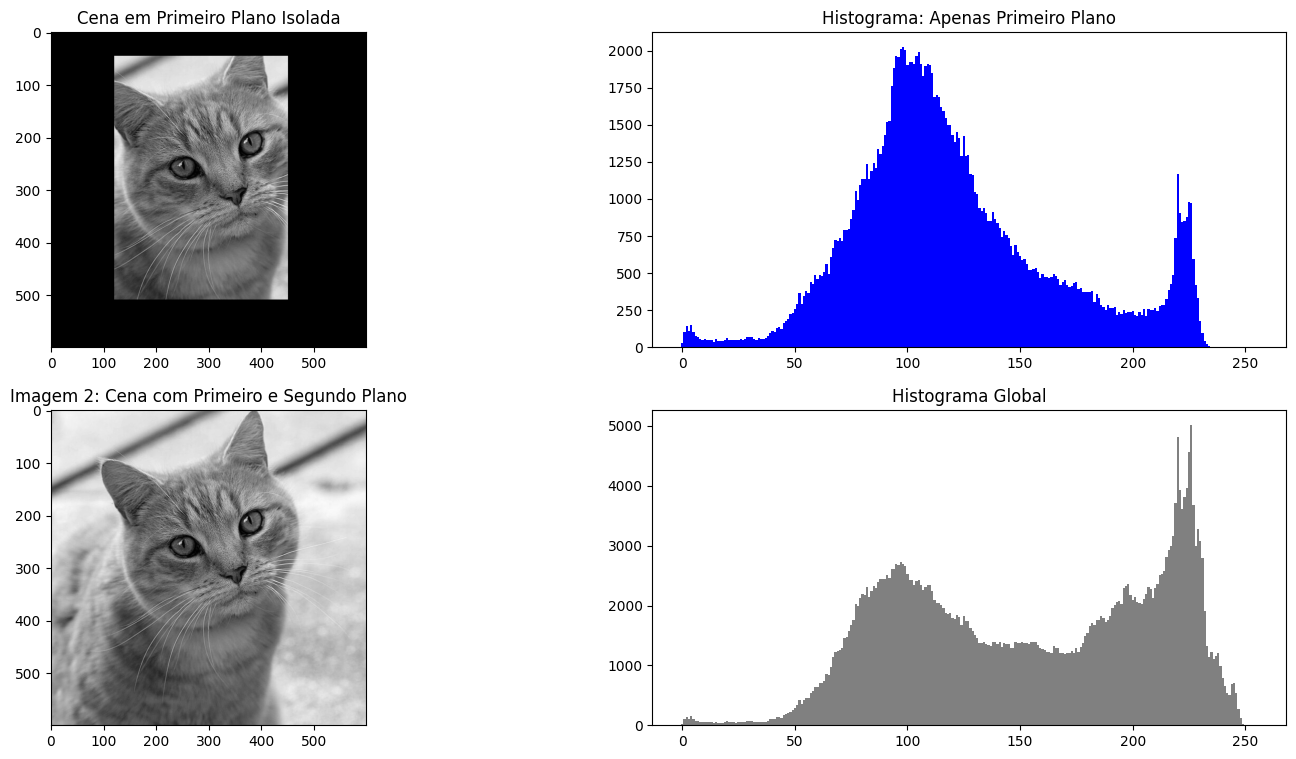

In [169]:
# Criar a máscara binária manualmente:
mask = np.zeros_like(img_new_array)
altura, largura = img_new_array.shape

# Definir um retângulo que envolve o primeiro plano
margem_superior = 0.08
margem_inferior = 0.85
margem_esquerda = 0.20
margem_direita  = 0.75

linha_inicio = int(altura  * margem_superior)
linha_fim    = int(altura  * margem_inferior)
coluna_inicio = int(largura * margem_esquerda)
coluna_fim    = int(largura * margem_direita)

mask[linha_inicio : linha_fim, coluna_inicio : coluna_fim] = 1

# Aplicar a máscara para isolar a cena
img_black = img_new_array * mask

# Exibir o histograma apenas da área da máscara
pixels_fg = img_new_array[mask == 1]
hist_fg = my_histogram(pixels_fg)

# Exibir os resultados
fig, ax = plt.subplots(2, 2, figsize=(18, 9))

ax[0][0].imshow(img_black, cmap='gray')
ax[0][0].set_title("Cena em Primeiro Plano Isolada")
ax[0][1].bar(range(256), hist_fg, color='blue', width=1.0)
ax[0][1].set_title("Histograma: Apenas Primeiro Plano")

ax[1][0].imshow(img_new_array, cmap='gray')
ax[1][0].set_title("Imagem 2: Cena com Primeiro e Segundo Plano")
ax[1][1].bar(range(256), hist_global, color='gray', width=1.0)
ax[1][1].set_title("Histograma Global")
plt.show()

Para isolar o primeiro plano, criou-se uma máscara binária manual. A máscara é uma matriz do mesmo tamanho da imagem, onde o valor 1 representa o que queremos manter (o gato) e 0 o que queremos ignorar (o fundo)

Discussão: O histograma do primeiro plano (o gato) mostra picos mais definidos. Se o gato tiver pelos mais claros que o fundo, o histograma do primeiro plano estará mais deslocado para a direita em comparação ao fundo. Isso prova que o primeiro plano possui uma distribuição tonal distinta da composição total da foto.